In [2]:
import numpy as np
import pandas as pd

data_fil = pd.read_csv('../data/mock_withfilament.csv')
data_gxs = pd.read_csv('../data/to_mock.csv')
print(data_fil.head())
print(data_gxs.head())

# Print data_gxs min and max coordinates
print("data_gxs min coordinates:")
print(data_gxs[['x', 'y', 'z']].min())
print("data_gxs max coordinates:")
print(data_gxs[['x', 'y', 'z']].max())


   id   ifil       dfil       long        vx        vy        vz      vx_s  \
0   0  40167   4.553721  17.433956 -0.411057 -0.139315 -0.900901 -0.411057   
1   1  40135  23.632212  48.270763 -0.009530 -0.018560  0.999782 -0.009530   
2   2  40135  11.512803  48.270763  0.337681 -0.309021  0.889088  0.337681   
3   3  40150  19.133562  24.687315  0.538855  0.707508 -0.457239  0.538855   
4   4  40136   2.747936  14.980529 -0.653020 -0.753986 -0.071210 -0.653020   

       vy_s      vz_s  
0 -0.139315 -0.900901  
1 -0.018560  0.999782  
2 -0.309021  0.889088  
3  0.707508 -0.457239  
4 -0.753986 -0.071210  
          x        y        z      vx      vy      vz  magstarsdssr
0   5.07982  54.8365  26.0467  134.67  -69.30 -348.55      -20.4510
1  25.54040  18.9353  29.7675 -280.47   37.10   66.41      -21.6621
2  11.52790  18.8106  38.0231 -264.39 -365.38   39.71      -20.2699
3  10.37660  43.5003  69.2261 -119.96 -167.24  220.22      -20.2940
4  26.45570  22.9552  42.7072 -539.48 -374.27  

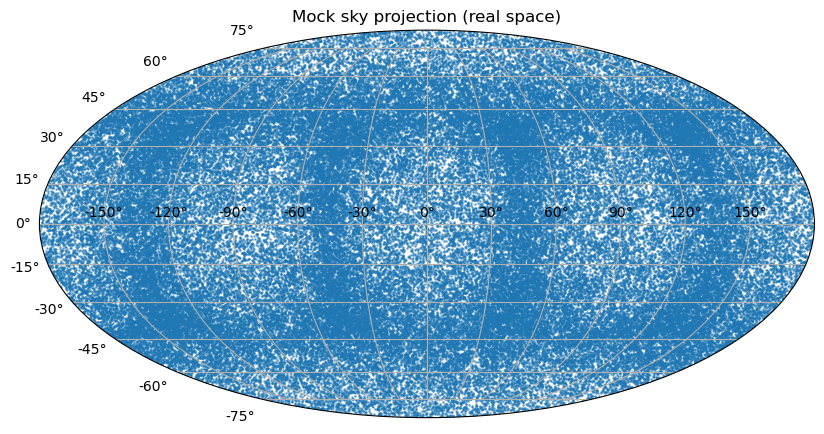

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/to_mock.csv")

x = df["x"].values
y = df["y"].values
z = df["z"].values

# --- Correct centering ---
x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# Distance
r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

# Angles
ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

dec = np.degrees(np.arcsin(z_c / r))

# Convert to Mollweide coords
ra_rad = np.radians(ra - 180)
dec_rad = np.radians(dec)

# --- Proper dilution ---
idx = np.random.choice(len(ra_rad), size=len(ra_rad)//100, replace=False)

plt.figure(figsize=(10,6))
ax = plt.subplot(111, projection="mollweide")

ax.scatter(ra_rad[idx], dec_rad[idx], s=1, alpha=0.5)

ax.set_title("Mock sky projection (real space)")
ax.grid(True)

plt.show()

### Radial cut

Total galaxies in data_gxs: 12142272
Distance stats:
Min distance: 1.98 Mpc/h
Max distance: 864.33 Mpc/h
Galaxies after distance cut: 2845980
Galaxies after dilution: 28459


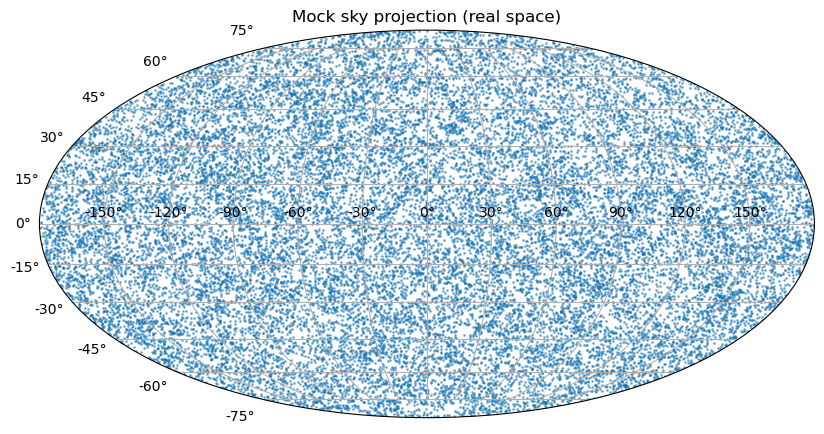

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/to_mock.csv")

print("Total galaxies in data_gxs:", len(df))

x = df["x"].values
y = df["y"].values
z = df["z"].values

# --- Correct centering ---
x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# Distance
r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

print("Distance stats:")
print(f"Min distance: {r.min():.2f} Mpc/h")
print(f"Max distance: {r.max():.2f} Mpc/h")

# Angles
ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

dec = np.degrees(np.arcsin(z_c / r))

# Convert to Mollweide coords
ra_rad = np.radians(ra - 180)
dec_rad = np.radians(dec)

# Apply distance cut
r_min = 200   # Mpc/h (choose something reasonable)
r_max = 400

mask = (r > r_min) & (r < r_max)

ra_sel  = ra_rad[mask]
dec_sel = dec_rad[mask]

print("Galaxies after distance cut:", len(ra_sel))

# --- Proper dilution ---
idx = np.random.choice(len(ra_sel), size=len(ra_sel)//100, replace=False)

print("Galaxies after dilution:", len(idx))

plt.figure(figsize=(10,6))
ax = plt.subplot(111, projection="mollweide")

ax.scatter(ra_sel[idx], dec_sel[idx], s=1, alpha=0.5)

ax.set_title("Mock sky projection (real space)")
ax.grid(True)

plt.show()

### Assign cosmological redshift and RSD

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

# ============================================================
# 1. Load data and merge filament distances
# ============================================================

df = pd.read_csv("../data/to_mock.csv")
df_fil = pd.read_csv("../data/mock_withfilament.csv")

# Attach dist_fil (handle both naming conventions)
if "dist_fil" in df_fil.columns:
    df["dist_fil"] = df_fil["dist_fil"].values
elif "dfil" in df_fil.columns:
    df["dist_fil"] = df_fil["dfil"].values
else:
    raise ValueError("No dist_fil/dfil column found in filament file")

print("Columns:", df.columns)

# ============================================================
# 2. Extract arrays
# ============================================================

x = df["x"].values
y = df["y"].values
z = df["z"].values

vx = df["vx"].values
vy = df["vy"].values
vz = df["vz"].values

dist_fil = df["dist_fil"].values

mag_r = df['magstarsdssr'].values

# ============================================================
# 3. Center coordinates around observer
# ============================================================

x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# ============================================================
# 4. Compute distances and angles
# ============================================================

r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

# Avoid division by zero
with np.errstate(invalid='ignore'):
    dec = np.degrees(np.arcsin(z_c / r))

ra_rad = np.radians(ra)
dec_rad = np.radians(dec)


# ============================================================
# 6. Cosmology: distance -> redshift
# ============================================================

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)

z_grid = np.linspace(0, 1, 1000)
r_grid = cosmo.comoving_distance(z_grid).value
r_to_z = interp1d(r_grid, z_grid, bounds_error=False, fill_value="extrapolate")

z_cosmo = r_to_z(r)

# ============================================================
# 7. LOS velocities (RSD)
# ============================================================

nx = x_c / r
ny = y_c / r
nz = z_c / r

v_los = vx * nx + vy * ny + vz * nz

c = 3e5  # km/s
z_obs = z_cosmo + v_los / c

# ============================================================
# 7. Redshift+Magnitude cut
# ============================================================

zmin = 0.07
zmax = 0.12
mag_cut = -21.5
mask = (z_obs > zmin) & (z_obs < zmax) & (mag_r < mag_cut)

# Apply to everything
x_c = x_c[mask]
y_c = y_c[mask]
z_c = z_c[mask]

vx = vx[mask]
vy = vy[mask]
vz = vz[mask]

r = r[mask]

ra = ra[mask]
ra_rad = ra_rad[mask]
dec_rad = dec_rad[mask]

dist_fil = dist_fil[mask]
mag_r = mag_r[mask]

z_cosmo = z_cosmo[mask]
z_obs = z_obs[mask]

import healpy as hp

# ============================================================
# 8. Angular selection – healpy mask
# ============================================================

# Load random catalog (already done)
randoms = pd.read_csv("../data/lss_randoms_combined_cut_LARGE.csv")
ra_random = randoms["ra"].values
dec_random = randoms["dec"].values

# Choose HEALPix resolution (nside). 
# nside = 1024 gives pixels of ~3.4 arcmin, good for most survey masks.
# nside = 2048 gives ~1.7 arcmin, but uses 4× more memory (still fine).
nside = 256

# Convert random coordinates to pixel indices (nested ordering for fast indexing)
theta_random = np.radians(90.0 - dec_random)   # colatitude in radians
phi_random   = np.radians(ra_random)           # longitude in radians
pix_random = hp.ang2pix(nside, theta_random, phi_random, nest=True)

# Unique occupied pixels (or create a boolean mask)
occupied = np.zeros(hp.nside2npix(nside), dtype=bool)
# Using np.unique to avoid assigning many times to same pixel
unique_pix = np.unique(pix_random)
occupied[unique_pix] = True

# Galaxy coordinates (already in radians for dec_rad, ra_rad)
theta_gal = np.pi/2.0 - dec_rad   # dec_rad is in radians (from your code)
phi_gal   = ra_rad                 # ra_rad in radians
pix_gal = hp.ang2pix(nside, theta_gal, phi_gal, nest=True)

# Mask: keep galaxies whose pixel is occupied
mask_ang = occupied[pix_gal]

# Apply the mask to all relevant arrays
x_c = x_c[mask_ang]
y_c = y_c[mask_ang]
z_c = z_c[mask_ang]
vx = vx[mask_ang]
vy = vy[mask_ang]
vz = vz[mask_ang]
r = r[mask_ang]
ra = ra[mask_ang]
ra_rad = ra_rad[mask_ang]
dec_rad = dec_rad[mask_ang]
dist_fil = dist_fil[mask_ang]
mag_r = mag_r[mask_ang]
z_cosmo = z_cosmo[mask_ang]
z_obs = z_obs[mask_ang]

# ============================================================
# 8. Convert to redshift-space positions
# ============================================================

# Recompute unit vectors after angular mask
nx = x_c / r
ny = y_c / r
nz = z_c / r

r_obs = cosmo.comoving_distance(z_obs).value

x_rsd = r_obs * nx
y_rsd = r_obs * ny
z_rsd = r_obs * nz

# ============================================================
# 10. Save lightcone catalog
# ============================================================

out_df = pd.DataFrame({
    "x_real": x_c,
    "y_real": y_c,
    "z_real": z_c,
    "x_rsd": x_rsd,
    "y_rsd": y_rsd,
    "z_rsd": z_rsd,
    "ra_deg": ra,
    "dec_deg": np.degrees(dec_rad),
    "z_cosmo": z_cosmo,
    "z_obs": z_obs,
    "dist_fil": dist_fil,
    "mag_r": mag_r
})

print(f"Number of galaxies: {len(out_df)}")

output_file = "../data/lightcone_real_and_rsd_withfil.csv"
out_df.to_csv(output_file, index=False)

print(f"Saved lightcone to: {output_file}")

# ============================================================
# Plots
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# RA/Dec plot
plt.figure(figsize=(10,6))
plt.scatter(np.degrees(ra_rad), np.degrees(dec_rad), s=1, alpha=0.5)
plt.title("Light-cone sky projection (RA/Dec)")
plt.grid(True)
plt.show()


# --- Subsample for plotting (optional, for speed) ---
N_plot = min(5_000_000, len(x_c))
idx = np.random.choice(len(x_c), size=N_plot, replace=False)

# Transverse coordinate (X)
x_trans = x_c[idx]

# LOS distances
r_los_real = r[idx]       # real-space
r_los_rsd  = r_obs[idx]   # redshift-space

# --- 2D histogram parameters ---
bins_x = 150   # transverse bins
bins_y = 150   # LOS bins

vmin = None    # can fix min/max to same scale for both plots
vmax = None

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Real-space density
h0 = axes[0].hist2d(x_trans, r_los_real, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[0].set_xlabel("X [Mpc/h]")
axes[0].set_ylabel("LOS distance [Mpc/h]")
axes[0].set_title("Real-space projection")

# Redshift-space density
h1 = axes[1].hist2d(x_trans, r_los_rsd, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[1].set_xlabel("X [Mpc/h]")
axes[1].set_title("Redshift-space projection")

# Colorbars
fig.colorbar(h0[3], ax=axes[0], label="Density")
fig.colorbar(h1[3], ax=axes[1], label="Density")

plt.suptitle("Light-cone wedge plots (2D histogram)")
plt.tight_layout()
plt.show()

Columns: Index(['x', 'y', 'z', 'vx', 'vy', 'vz', 'magstarsdssr', 'dist_fil'], dtype='object')


ValueError: operands could not be broadcast together with shapes (108745,) (607426,) 